# Tensor Basics


## 0. 环境配置与导入

环境搭建（虚拟环境、依赖安装、Jupyter 内核注册）详见仓库中的 `guide.md`。

确认环境就绪后，导入 PyTorch：

In [1]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0


## 1. 张量基础概念

张量（Tensor）是 PyTorch 的核心数据结构。

- 数学上的张量 ≠ 程序里的多维数组
- 但在 PyTorch / TensorFlow 等深度学习框架中，**实现层面张量就是封装好的多维数组**
- **n 维张量**：可以看作元素是 n-1 维张量的数组

> 讲解时可结合线性代数，用平板手写说明张量的维度、形状。尤其是如何不允许代码写出张量的shape，核心是从外到内看括号，利用前面n维张量就是n-1维张量的数组的递归思想。

In [2]:
# 标量（0维）
a = torch.tensor(1)
b = torch.tensor(0)

# 向量（1维）
x = torch.tensor([1])
x1 = torch.tensor([1, 2, 3])

# 矩阵（2维）
y = torch.tensor([[1, 2], [3, 4]])

# 3维张量
z = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

# shape 属性返回 torch.Size（本质是 tuple）；Jupyter 中最后一行直接输出，无需 print
a.shape, b.shape, x.shape, x1.shape, y.shape, z.shape

# ---- 探索区（取消注释逐行运行）----
# a.size(), b.size(), x.size(), x1.size(), y.size(), z.size()            # size() 是方法，与 shape 属性输出相同，但两者有细微差别
# a.dim(), b.dim(), x.dim(), x1.dim(), y.dim(), z.dim()                  # dim() 返回维度数（标量0，向量1，矩阵2...）
# torch.tensor(1).shape, torch.tensor(1).size(), torch.tensor(1).dim()   # 不赋值给变量也能直接查看

(torch.Size([]),
 torch.Size([]),
 torch.Size([1]),
 torch.Size([3]),
 torch.Size([2, 2]),
 torch.Size([2, 2, 2]))

In [3]:
# torch.Size 本质是 tuple，支持索引、len()、list() 等操作
s = torch.Size([2, 3, 4])
print(s)
print("s[0], s[1], s[2] =", s[0], s[1], s[2])
print("len(s) =", len(s))       # torch.Size 没有 .dim() 方法，torch.tensor才有，用 len() 获取维度数
print("list(s) =", list(s))
print("tuple(s) =", tuple(s))

# 越界访问会报错
try:
    print(s[3])
except Exception as e:
    print(f"Error: {e}")

torch.Size([2, 3, 4])
s[0], s[1], s[2] = 2 3 4
len(s) = 3
list(s) = [2, 3, 4]
tuple(s) = (2, 3, 4)
Error: tuple index out of range


## 2. 张量创建方法

In [4]:
# 1. 从 Python 列表创建
t1 = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

# 指定数据类型（data-type) dtype（常用 torch.float32：硬件适配最好，精度与速度均衡）
t2 = torch.tensor([1, 2, 3], dtype=torch.float32)

# 2. 全 0 / 全 1
t_zeros = torch.zeros(2, 3)
t_ones = torch.ones(2, 3)

# 3. 随机初始化
t_rand = torch.rand(2, 3)     # [0, 1) 均匀分布
t_randn = torch.randn(2, 3)   # 标准正态分布 N(0,1)，每个元素独立采样

# 4. 不初始化（值为内存垃圾，不可预测，不建议使用）
t_empty = torch.empty(2, 3)

print("t1:", t1)
print("t2:", t2)
print("t_zeros:", t_zeros)
print("t_ones:", t_ones)
print("t_rand:", t_rand)
print("t_randn:", t_randn)
print("t_empty:", t_empty)

t1: tensor([[1., 2.],
        [3., 4.]])
t2: tensor([1., 2., 3.])
t_zeros: tensor([[0., 0., 0.],
        [0., 0., 0.]])
t_ones: tensor([[1., 1., 1.],
        [1., 1., 1.]])
t_rand: tensor([[0.2363, 0.0441, 0.0522],
        [0.8086, 0.9990, 0.5012]])
t_randn: tensor([[ 0.9415,  0.6391,  0.1688],
        [ 1.6137, -0.4976,  1.7882]])
t_empty: tensor([[0., 0., 0.],
        [0., 0., 0.]])


## 3. 数据类型 dtype

In [5]:
t_int32 = torch.tensor([1, 2], dtype=torch.int32)
t_fp32 = torch.tensor([1.0, 2.0], dtype=torch.float32)
t_fp64 = torch.tensor([1.0, 2.0], dtype=torch.float64)

print("int32:", t_int32.dtype)
print("float32:", t_fp32.dtype)
print("float64:", t_fp64.dtype)

# 类型转换：.to(dtype)
t = torch.tensor([1, 2])          # 整数列表默认 int64
print("before:", t.dtype)
t_float = t.to(torch.float32) # t_float = t.to(dtype=torch.float32) 效果一样
print("after: ", t_float.dtype)

int32: torch.int32
float32: torch.float32
float64: torch.float64
before: torch.int64
after:  torch.float32


## 4. 统计量入门：mean / std

In [6]:
x = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])

print("mean:", x.mean())    # 全部 4 个元素求平均 → 2.5
print("std: ", x.std())     # 样本标准差（默认 unbiased=True，分母 N-1），结果约为 1.2910

mean: tensor(2.5000)
std:  tensor(1.2910)


In [7]:
# rand  vs  randn 对比
# rand(random):  [0, 1) 均匀分布，永远不会出现负数
r1 = torch.rand(10000)
print("rand  min/max:", r1.min().item(), r1.max().item())

# randn(random normal): 标准正态 N(0,1)，有正有负，均值接近 0，标准差接近 1
r2 = torch.randn(10000)
print("randn mean/std:", r2.mean().item(), r2.std().item())
print("randn min/max:", r2.min().item(), r2.max().item())

# std() 的 unbiased 参数：
#   unbiased=True （默认）：样本标准差，分母 N-1（贝塞尔校正）
#   unbiased=False        ：总体标准差，分母 N，数学中的标准差定义
data = torch.tensor([1., 2., 3.])
print("unbiased=False (总体, 分母 N):  ", data.std(unbiased=False).item())
print("unbiased=True  (样本, 分母 N-1):", data.std().item())

rand  min/max: 3.504753112792969e-05 0.9999610781669617
randn mean/std: -0.010698196478188038 0.9983021020889282
randn min/max: -3.7190632820129395 3.6460399627685547
unbiased=False (总体, 分母 N):   0.8164966106414795
unbiased=True  (样本, 分母 N-1): 1.0


Matplotlib is building the font cache; this may take a moment.


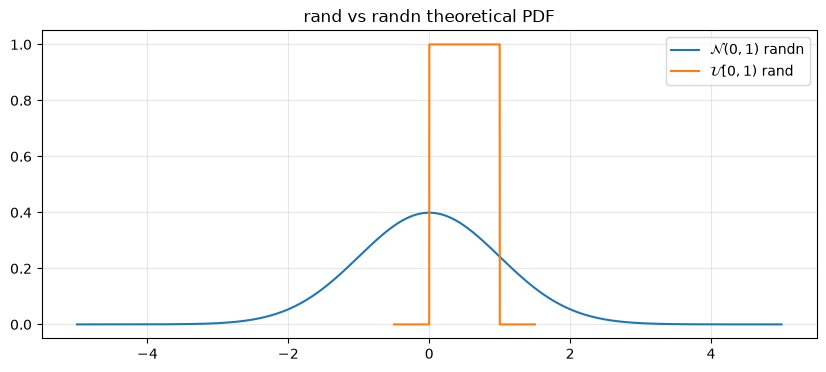

In [ ]:
# 直观展示，绘图直接内嵌在单元格输出里，不用弹出独立绘图窗口
%matplotlib inline
import torch
import matplotlib.pyplot as plt

# -------- 正态 N(0,1) --------
x_norm = torch.linspace(-5, 5, 10000)
mu, sigma = 0, 1
norm_coeff_norm = 1.0 / (torch.sqrt(torch.tensor(2 * torch.pi)) * sigma)
exponent_norm = - (x_norm - mu) ** 2 / (2 * sigma ** 2)
pdf_norm = norm_coeff_norm * torch.exp(exponent_norm)

# -------- 均匀 U[0,1) --------
x_unif = torch.linspace(-0.5, 1.5, 10000)
a, b = 0, 1
norm_coeff_unif = 1.0 / (b - a)
pdf_unif = torch.where((x_unif >= a) & (x_unif < b), torch.tensor(norm_coeff_unif), torch.tensor(0.0))

plt.figure(figsize=(10,4))
plt.plot(x_norm.numpy(), pdf_norm.numpy(), label=r"$\mathcal{N}(0,1)$ randn")
plt.plot(x_unif.numpy(), pdf_unif.numpy(), label=r"$\mathcal{U}[0,1)$ rand")
plt.grid(alpha=0.3)
plt.legend()
plt.title("rand vs randn theoretical PDF")
plt.show()


### 概率密度函数 PDF ( probability density function )
#### 1. 标准正态分布 $\mathcal{N}(\mu,\sigma^2)$
概率密度函数：
$$
f(x)=\frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),\quad x\in\mathbb R
$$

**标准正态分布（$\boldsymbol{\mu=0,\ \sigma=1}$）$\mathcal{N}(0,1)$**
$$
f(x)=\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{x^2}{2}\right),\quad x\in\mathbb R
$$

- $\mu$：均值
- $\sigma$：标准差，$\sigma^2$ 为方差
- 对应 PyTorch：`torch.randn()`

---

#### 2. 连续(均匀分布) $\mathcal{U}[a,b)$

概率密度函数：
$$
f(x)=
\begin{cases}
\displaystyle \frac{1}{b-a}, & a\le x < b \\[4pt]
0, & \text{其它}
\end{cases}
$$

**$\boldsymbol{\mathcal{U}[0,1)}$**
$$
f(x)=
\begin{cases}
1, & 0\le x < 1 \\
0, & \text{其它}
\end{cases}
$$

- $a$：区间下界
- $b$：区间上界
- 对应 PyTorch：`torch.rand()`

> 说明：PDF（概率密度）本身不等于概率；在区间上对PDF积分才得到概率：$P(x_1<X<x_2)=\int_{x_1}^{x_2}f(x)\mathrm{d}x$。


In [9]:
# 整数张量不支持 mean() / std()，需要先转 float
xi = torch.tensor([1, 2, 3])

# ---- 取消注释查看报错 ----
# xi.mean()
# xi.std()
# RuntimeError: mean(): could not infer output dtype.
# Input dtype must be either a floating point or complex dtype.

# 正确做法：先转 float
print(xi.float().mean())

tensor(2.)


## 5. 形状操作：reshape / unsqueeze / squeeze

In [10]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # shape [2, 3]

# reshape：改变形状，元素总数必须相等
x1 = x.reshape(6)
print("reshape(6):", x1.shape, "\n", x1)

x2 = x.reshape(3, 2)
print("reshape(3,2):", x2.shape, "\n", x2)

# unsqueeze：插入长度为 1 的维度
x3 = x.unsqueeze(0)   # 在 0 维插入，shape [1, 2, 3]
print("unsqueeze(0):", x3.shape)

# squeeze：删除长度为 1 的维度
x4 = x3.squeeze(0)
print("squeeze(0):", x4.shape)

# -1：自动推导该维度长度（总数 6，另一维 = 6/2 = 3）
x5 = x.reshape(-1, 2)
print("reshape(-1, 2):", x5.shape)

reshape(6): torch.Size([6]) 
 tensor([1, 2, 3, 4, 5, 6])
reshape(3,2): torch.Size([3, 2]) 
 tensor([[1, 2],
        [3, 4],
        [5, 6]])
unsqueeze(0): torch.Size([1, 2, 3])
squeeze(0): torch.Size([2, 3])
reshape(-1, 2): torch.Size([3, 2])


## 6. 广播机制 Broadcasting

In [11]:
A = torch.tensor([[1], [2], [3]])  # shape [3, 1]
B = torch.tensor([10, 20])               # shape [2]

C = A + B   # 广播后 shape [3, 2]
print("A shape:", A.shape)
print("B shape:", B.shape)
print("C:\n", C)
print("C shape:", C.shape)

A shape: torch.Size([3, 1])
B shape: torch.Size([2])
C:
 tensor([[11, 21],
        [12, 22],
        [13, 23]])
C shape: torch.Size([3, 2])


两个不同 shape 的张量做逐元素运算（`+ - * /`）时，不需要手动复制扩张数据，而是**虚拟地把张量拉伸到相同 shape 再运算**，不产生新拷贝，内存高效。

> 广播只作用于**逐元素算子**；矩阵乘法 `@` 不受广播支配（batch 维除外）。

**规则：从最右侧维度（最后一维）开始向左两两比对：**

1. 对应维度长度**相等**，或者其中一个为 **1**
2. 其中一个张量该维度不存在（维度数更少），视为该维度大小为 1
3. 广播后的维度取较大值

> 建议用平板手写演示广播的数学计算过程。

## 7. 原地操作 In-place

PyTorch 中方法名以下划线 `_` 结尾的是**原地操作**（in-place），直接修改张量本身，不返回新张量。

In [12]:
x = torch.tensor([1.0, 2.0])

# 非原地：返回新张量，x 不变
y = x.add(5)
print("x after add():", x)
print("y after add():", y)

# 原地：下划线后缀，直接修改 x
x.add_(5)
print("x after add_():", x)

# 原地操作返回的就是原对象
a = torch.tensor([[1, 2], [3, 4]])
c = a.add_(5) # 这里其实用了广播机制
print("c is a:", c is a)   # True，c 和 a 指向同一个对象
print("a after add_():", a)

x after add(): tensor([1., 2.])
y after add(): tensor([6., 7.])
x after add_(): tensor([6., 7.])
c is a: True
a after add_(): tensor([[6, 7],
        [8, 9]])


In [13]:
a = torch.tensor([10., 20., 30.])
b = torch.tensor([2., 4., 5.])

# 减法 sub / sub_
print("sub  非原地:", a.sub(b))
a.sub_(b)
print("sub_ 原地后 a:", a)

# 乘法 mul / mul_（逐元素乘）
a = torch.tensor([10., 20., 30.])
print("mul  非原地:", a.mul(b))
a.mul_(b)
print("mul_ 原地后 a:", a)

# 除法 div / div_
a = torch.tensor([10., 20., 30.])
print("div  非原地:", a.div(b))
a.div_(b)
print("div_ 原地后 a:", a)

# 运算符简写（也是原地操作）
a = torch.tensor([10., 20., 30.])
a -= b
a *= 2
a /= 3
print("运算符结果:", a)

sub  非原地: tensor([ 8., 16., 25.])
sub_ 原地后 a: tensor([ 8., 16., 25.])
mul  非原地: tensor([ 20.,  80., 150.])
mul_ 原地后 a: tensor([ 20.,  80., 150.])
div  非原地: tensor([5., 5., 6.])
div_ 原地后 a: tensor([5., 5., 6.])
运算符结果: tensor([ 5.3333, 10.6667, 16.6667])


> 注意：`requires_grad=True` 的张量尽量不要使用原地操作，容易破坏计算图，导致反向传播报错。

## 8. 拼接与堆叠：cat / stack

In [14]:
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])

# cat：在已有维度上拼接，不新增维度
c_cat0 = torch.cat([a, b], dim=0)
print("cat dim=0 shape:", c_cat0.shape)   # [4, 2]
print(c_cat0)

c_cat1 = torch.cat([a, b], dim=1)
print("cat dim=1 shape:", c_cat1.shape)   # [2, 4]
print(c_cat1)

# stack：先新增一个维度，再沿新维度堆叠
c_stack0 = torch.stack([a, b], dim=0)
print("stack dim=0 shape:", c_stack0.shape)  # [2, 2, 2]
print(c_stack0)

c_stack1 = torch.stack([a, b], dim=1)
print("stack dim=1 shape:", c_stack1.shape)  # [2, 2, 2]
print(c_stack1)

cat dim=0 shape: torch.Size([4, 2])
tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])
cat dim=1 shape: torch.Size([2, 4])
tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]])
stack dim=0 shape: torch.Size([2, 2, 2])
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
stack dim=1 shape: torch.Size([2, 2, 2])
tensor([[[1, 2],
         [5, 6]],

        [[3, 4],
         [7, 8]]])


- `torch.cat`：在**已有的某一个维度**上拼接，**不新增维度**。
- `torch.stack`：**先新增一个全新维度**，再沿着这个新维度堆叠。
这部分用平板演示如何从数学角度，不允许代码直接得到结果。
- stack([A,B], dim=0)
把完整的A、B各自作为新维度下的一整个切片，在外层顺序摆放，相当于把两张完整书页叠成一本书。

- stack([A,B], dim=1)
按行两两配对，A的每一行和B的对应行打包一组，在原有行、列中间插入新维度。

- stack([A,B], dim=2)
按元素位置两两配对，A、B同一坐标的数字组成小组盒，把新维度加在张量最内层。

## 9. 按维度统计：sum / dim / keepdim

In [15]:
t = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

# 不指定 dim：对所有元素求和，返回标量
s = t.sum()
print("sum all:", s, s.shape)        # 10.0，shape []

# dim=0：沿第 0 维（行方向）求和，即每一列的和
s0 = t.sum(dim=0)
print("sum dim=0:", s0, s0.shape)        # [4, 6]

# dim=1：沿第 1 维（列方向）求和，即每一行的和
s1 = t.sum(dim=1)
print("sum dim=1:", s1, s1.shape)        # [3, 7]

# keepdim=True：保留被求和的维度（长度变为 1），注意输出中括号的个数
s0_keep = t.sum(dim=0, keepdim=True)
print("sum dim=0 keepdim:", s0_keep, s0_keep.shape)  # [[4, 6]]
s1_keep = t.sum(dim=1, keepdim=True)
print("sum dim=1 keepdim:", s1_keep, s1_keep.shape)  # [[3], [7]]

sum all: tensor(10.) torch.Size([])
sum dim=0: tensor([4., 6.]) torch.Size([2])
sum dim=1: tensor([3., 7.]) torch.Size([2])
sum dim=0 keepdim: tensor([[4., 6.]]) torch.Size([1, 2])
sum dim=1 keepdim: tensor([[3.],
        [7.]]) torch.Size([2, 1])


## 10. 自动求导入门

PyTorch 的自动微分（autograd）是深度学习训练的核心。设置 `requires_grad=True` 后，PyTorch 会追踪该张量上的所有操作，构建计算图；调用 `.backward()` 后自动计算梯度。

In [16]:
x = torch.tensor([1.0, 2.0], requires_grad=True)
y = x ** 2        # y = [1, 4]，对每个元素2次方。
loss = y.sum()    # loss = 5

loss.backward()   # 反向传播，计算 d(loss)/dx
print("y =", y)
print("x.grad =", x.grad)   # d(loss)/dx = 2*x = [2, 4]

y = tensor([1., 4.], grad_fn=<PowBackward0>)
x.grad = tensor([2., 4.])


> 梯度部分用平板补充一点数学上的计算。因为梯度在深度学习中太重要了。

## 课后练习

### 基础题

1. 创建一个 shape 为 `[3, 4]` 的随机张量（标准正态分布），计算其所有元素的均值和标准差。
2. 将上题的张量 reshape 为 `[2, 6]`，再 unsqueeze 一个维度变成 `[1, 2, 6]`。
3. 已知 `A = torch.tensor([[1, 2], [3, 4]])`，`B = torch.tensor([10, 20])`，用广播机制计算 `A + B`，并手写验证每一步的广播过程。
4. 用 `torch.stack` 将两个 shape 为 `[3]` 的向量堆叠成 `[2, 3]`，再用 `torch.cat` 尝试同样操作，观察两者的区别。
5. 设置 `x = torch.tensor([2.0, 3.0], requires_grad=True)`，计算 `y = (x ** 3).sum()`，调用 backward 后验证 `x.grad` 是否等于 `3 * x ** 2`。

### dtype 与类型转换

6. 创建 `torch.tensor([1, 2, 3, 4])`，观察默认 dtype；尝试直接调用 `.mean()`（会报错），用 `.float()` 转换后再计算。
7. 分别用 `dtype=torch.float32` 和 `dtype=torch.float64` 创建两个 `[1000, 1000]` 的随机张量，用 `.element_size() * .numel()` 计算内存占用，对比精度与内存的权衡。

### 原地操作

8. `x = torch.tensor([1.0, 2.0])`，先执行 `y = x + 1`，观察 x 和 y 的值与 `id()`；再执行 `x.add_(1)`，观察 x 的值和 `id()` 是否变化。解释为什么深度学习框架要提供原地操作。

### 按维度统计

9. 创建 `[4, 5]` 的随机张量，分别计算 `dim=0`（按列）和 `dim=1`（按行）的 `sum` 与 `mean`，写出每个输出的 shape 并解释含义。
10. 对上题的张量，分别用 `keepdim=True` 和 `keepdim=False` 计算行均值，观察输出 shape 的区别；然后用广播实现"每行减去该行均值"（行中心化），验证结果每行均值≈0。

### 综合应用

11. 数据标准化：创建 `[100, 5]` 的标准正态随机张量 X，计算每列的均值和标准差，用广播实现 `X_norm = (X - mean) / std`，验证 X_norm 每列的均值≈0、标准差≈1。
12. 批量 L2 归一化：创建 `[32, 10]` 的随机张量（模拟 batch_size=32，10 个特征），按 `dim=1` 计算每个样本的 L2 范数（平方和开方），然后用广播将每个样本除以其范数，验证归一化后每个样本的范数≈1。

### 自动求导进阶

13. 设置 `x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)`，计算 `y = (torch.sin(x) * x**2).sum()`，调用 `backward()`。手动用乘积法则推导梯度 `dy/dx = cos(x)·x² + sin(x)·2x`，用代码验证 `x.grad`。
